# Estudio del sistema Saturno-Titán-Hiperion con la teoría del CRTBP

https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Modelacion3/CalculosCRTBP.ipynb

In [ ]:
!pip install -Uq pymcel celluloid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.7 MB/s eta 0:00:00


In [ ]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


### Consulta de Efemérides con Horizons

Para inicializar la simulación del sistema Saturno-Titán-Hiperión, es necesario obtener las condiciones iniciales precisas (posición y velocidad) de cada cuerpo. Utilizamos la función `pc.consulta_horizons` para extraer los vectores de estado desde la base de datos JPL Horizons.

1.  Definimos el intervalo temporal (`Epochs`) de un mes (junio-julio 2026) con pasos diarios.
2.  Especificamos los identificadores NAIF de los cuerpos: Saturno (`699`), Titán (`606`) e Hiperión (`607`).
3.  Iteramos sobre cada cuerpo para descargar sus tablas de efemérides, tiempos en Juliano (`tiempo_jd`) y vectores de estado (`vector_estado`), almacenándolos en diccionarios para su posterior procesamiento y transformación al sistema de referencia adecuado.

In [ ]:
Epochs = {'start': '2026-06-16', 'stop': '2026-07-16', 'step': '1m'}

ids = ["699","606","607"]

cuerpos = {
    "Saturno": "699",
    "Titan": "606",
    "Hiperion": "607"
}

all_tablas = {}
all_tiempo_jd = {}
all_vector_estado = {}

for name, body_id in cuerpos.items():
  tabla_body, tiempo_jd_body, vector_estado_body = pc.consulta_horizons(
      id=body_id,
      location='@6',
      epochs=Epochs,
      datos='vectors',
  )

  all_tablas[name] = tabla_body
  all_tiempo_jd[name] = tiempo_jd_body
  all_vector_estado[name] = vector_estado_body

tabla = all_tablas
tiempo_jd = all_tiempo_jd
vector_estado = all_vector_estado

### Configuración del CRTBP para el sistema Saturno-Titán-Hiperión

Para estudiar la dinámica de Hiperión ($m_3$) bajo la influencia gravitacional conjunta de Saturno ($m_1$) y Titán ($m_2$), asumimos que las órbitas de los cuerpos primarios son circulares alrededor de su centro de masas común.

Para simplificar las ecuaciones de movimiento, utilizamos un sistema de **unidades canónicas** donde:
*   La unidad de masa es $U_M = m_1 + m_2$.
*   La unidad de longitud es $U_L = a$, la distancia constante entre Saturno y Titán.
*   La unidad de tiempo se define tal que la velocidad angular media del sistema sea $n=1$, lo que implica $U_T = \sqrt{\frac{U_L^3}{G U_M}}$.

En este sistema adimensional, el parámetro de masa $\alpha$ corresponde a la fracción de masa del cuerpo secundario (Titán), definido como $\alpha = \mu_2 = G m_2$, mientras que la masa reducida del cuerpo primario es $\mu_1 = 1-\alpha$.

In [ ]:
G = pc.constantes.G
m1 = pc.constantes.mu_saturn/G    # Masa de saturno
m2 = 1.345e23                     # Masa de titán
m3 = 5.686e18                     # Masa de hiperion

a = 1.2218e9

# Definimos unidades canonicas
U_M = m1+m2
U_L = a
U_T = np.sqrt(U_L**3/(G*U_M))
U_V = U_L/U_T

mu2 = m2*G / (G*U_M)
alpha = mu2
mu1 = 1-alpha

# Implementación numérica de las ecuaciones de movimiento del CRTBP

Para analizar el movimiento de la partícula de prueba ($m_3$) en el Problema Circular Restringido de los Tres Cuerpos (CRTBP), es conveniente trabajar en un sistema de referencia no inercial que rota con velocidad angular constante $\vec{\omega} = n \hat{k}$, donde $n$ es la velocidad media del sistema binario. En este marco, las dos masas primarias permanecen fijas sobre el eje $x$.

La ecuación vectorial de movimiento general en un sistema rotante, incluye los términos gravitacionales y las fuerzas ficticias (centrífuga y de Coriolis):

$$ \ddot{\vec{r}} = -\frac{\mu_1}{r_1^3}\vec{r}_1 - \frac{\mu_2}{r_2^3}\vec{r}_2 - \vec{\omega} \times (\vec{\omega} \times \vec{r}) - 2\vec{\omega} \times \dot{\vec{r}} $$

Donde:
*   $\vec{r}_1$ y $\vec{r}_2$ son los vectores posición relativos desde la partícula de prueba hacia $m_1$ y $m_2$.
*   El término $-\vec{\omega} \times (\vec{\omega} \times \vec{r})$ representa la **aceleración centrífuga**.
*   El término $-2\vec{\omega} \times \dot{\vec{r}}$ representa la **aceleración de Coriolis**.

Al introducir las **unidades canónicas** ($G=1, M=m_1+m_2=1, a=1, n=1$), los parámetros se simplifican notablemente: $\mu_1 = 1-\alpha$, $\mu_2 = \alpha$, y las posiciones de las masas primarias se fijan en $x_1 = -\alpha$ y $x_2 = 1-\alpha$.

Descomponiendo la ecuación vectorial en sus componentes cartesianas $(x, y, z)$ bajo estas unidades, obtenemos el sistema de ecuaciones diferenciales de segundo orden implementado en la función `edm_crtbp`:

$$
\begin{aligned}
\ddot{x} &= 2\dot{y} + x - \frac{(1-\alpha)(x+\alpha)}{r_1^3} - \frac{\alpha(x-1+\alpha)}{r_2^3} \\
\ddot{y} &= -2\dot{x} + y - \frac{(1-\alpha)y}{r_1^3} - \frac{\alpha y}{r_2^3} \\
\ddot{z} &= -\frac{(1-\alpha)z}{r_1^3} - \frac{\alpha z}{r_2^3}
\end{aligned}
$$


In [ ]:
def edm_crtbp(t, Ys, alpha):
  x, y, z, vx, vy, vz = Ys

  # Variables auxiliares
  x1 = -alpha # Posición del cuerpo 1
  x2 = 1 - alpha
  r1 = np.sqrt((x-x1)**2 + y**2 + z**2)
  r2 = np.sqrt((x-x2)**2 + y**2 + z**2)

  # Ecuaciones
  dx_dt = vx
  dy_dt = vy
  dz_dt = vz
  dvx_dt = +2*vy + x  - (1 - alpha) / r1**3 * (x - x1) - alpha / r2**3 * (x - x2)
  dvy_dt = -2*vx + y  - (1 - alpha) / r1**3 * y - alpha / r2**3 * y
  dvz_dt =            - (1 - alpha) / r1**3 * z - alpha / r2**3 * z

  return [dx_dt, dy_dt, dz_dt, dvx_dt, dvy_dt, dvz_dt]

### Transformación al Marco Rotante Canónico del CRTBP

Para resolver numéricamente las ecuaciones de movimiento del Problema Circular Restringido de los Tres Cuerpos (CRTBP), es necesario transformar el vector de estado de la partícula de prueba desde el sistema inercial original al **sistema de referencia rotante baricéntrico canónico**. Esta transformación es necesaria porque las ecuaciones simplificadas del CRTBP asumen que:
1.  El origen de coordenadas coincide con el centro de masas (baricentro) de los cuerpos primarios $m_1$ y $m_2$.
2.  Los ejes coordenados rotan con la misma velocidad angular $n$ que el sistema binario, manteniendo a $m_1$ y $m_2$ fijos sobre el eje $x$.
3.  Las unidades son adimensionales (canónicas), donde $G=1$, $M_{total}=1$ y la distancia entre primarios $a=1$.

La función `transformar_a_CRTBP_frame` realiza esta conversión mediante una composición de traslaciones, escalados y rotaciones. Matemáticamente, el proceso sigue estos pasos para un instante dado $t$:

1.  **Traslación al Baricentro:** Se calcula la posición $\vec{r}_{cm}$ y velocidad $\vec{v}_{cm}$ del baricentro del sistema binario. La posición y velocidad relativas de la partícula de prueba ($m_3$) en el sistema inercial centrado en el baricentro son:
$$ \vec{r}_{rel} = \vec{r}_3 - \vec{r}_{cm}, \quad \vec{v}_{rel} = \vec{v}_3 - \vec{v}_{cm} $$

2.  **Escalado a Unidades Canónicas:** Se normalizan las magnitudes usando los factores de conversión $U_L$ (longitud) y $U_V$ (velocidad):
$$ \vec{r}' = \frac{\vec{r}_{rel}}{U_L}, \quad \vec{v}' = \frac{\vec{v}_{rel}}{U_V} $$

3.  **Rotación al Eje Alineado:** Se determina el ángulo $\theta$ que forma el vector relativo entre los primarios $\vec{r}_{12} = \vec{r}_2 - \vec{r}_1$ con el eje $X$ inercial. Se aplica una matriz de rotación $R(-\theta)$ para alinear $\vec{r}_{12}$ con el eje $X$ del marco rotante:
$$ \vec{r}_{rot} = R(-\theta) \vec{r}' $$

4.  **Corrección de Velocidad Rotacional:** En un marco rotante, la velocidad observada $\vec{v}_{rot}$ difiere de la velocidad inercial rotada $\vec{v}'_{rot} = R(-\theta)\vec{v}'$ debido a la velocidad angular del sistema. En unidades canónicas, la velocidad angular es $\vec{\omega} = \hat{k}$ (magnitud 1). Por lo tanto, se resta el término de Coriolis/Centrífugo asociado a la transformación de velocidades.
$$ \vec{v}_{rot} = \vec{v}'_{rot} - (\vec{\omega} \times \vec{r}_{rot}) = R(-\theta)\vec{v}' - (\hat{k} \times \vec{r}_{rot}) $$

El vector final $\vec{Y} = [x, y, z, v_x, v_y, v_z]^T$ resultante está listo para ser integrado usando la función `edm_crtbp` definida previamente, garantizando consistencia con el formalismo teórico del CRTBP.

In [ ]:
def transformar_a_CRTBP_frame(estado_si, m1_si, m2_si, U_L, U_V):

    def get_vec(name):
        data = estado_si[name]
        if hasattr(data, 'values'): # Si es DataFrame
            return data[['x', 'y', 'z', 'vx', 'vy', 'vz']].iloc[0].to_numpy()
        else: # Si es array/lista
            return np.array(data[0]) # Asumiendo que es el primer instante

    r1_si = get_vec('Saturno')[:3]
    v1_si = get_vec('Saturno')[3:]

    r2_si = get_vec('Titan')[:3]
    v2_si = get_vec('Titan')[3:]

    r3_si = get_vec('Hiperion')[:3]
    v3_si = get_vec('Hiperion')[3:]

    # Calcular el Baricentro del sistema binario (m1 + m2)
    M_total = m1_si + m2_si

    r_cm_si = (m1_si * r1_si + m2_si * r2_si) / M_total
    v_cm_si = (m1_si * v1_si + m2_si * v2_si) / M_total

    # Trasladar al sistema centrado en el baricentro
    # (pero aún inercial y sin rotar)
    r_rel_si = r3_si - r_cm_si
    v_rel_si = v3_si - v_cm_si

    # Determinar el ángulo de rotación theta
    # El vector que define el eje X del sistema rotante es r12 (de m1 a m2)
    r12_si = r2_si - r1_si

    # Calculamos el ángulo que forma r12 con el eje X inercial
    # atan2(y, x) nos da el ángulo en el plano XY
    theta = np.arctan2(r12_si[1], r12_si[0])

    # Construir la Matriz de Rotación R(-theta)
    # Queremos rotar el sistema inercial para que r12 quede sobre el eje X.
    # Esto equivale a rotar los vectores por -theta.
    cos_t = np.cos(-theta)
    sin_t = np.sin(-theta)

    R = np.array([
        [cos_t, -sin_t, 0],
        [sin_t,  cos_t, 0],
        [0,      0,     1]
    ])

    # Aplicar la rotación a la posición relativa
    # r_rot = R * r_rel
    r_rot_si = np.dot(R, r_rel_si)

    # Aplicar la transformación de velocidad completa
    # v_rot = R * (v_rel - omega x r_rel)

    r_can_inertial = r_rel_si / U_L
    v_can_inertial = v_rel_si / U_V

    # Ahora aplicamos la rotación a las cantidades canónicas
    r_can_rot = np.dot(R, r_can_inertial)

    # Corrección de velocidad por rotación del marco:
    # v_rot = v_inertial_rotated - (omega_canonical x r_rot)
    # En unidades canónicas del CRTBP, la velocidad angular omega es 1 en dirección Z.
    omega_can = np.array([0, 0, 1])

    # Producto cruz omega x r
    omega_cross_r = np.cross(omega_can, r_can_rot)

    # Rotamos la velocidad inercial canónica
    v_can_inertial_rot = np.dot(R, v_can_inertial)

    # Velocidad final en el marco rotante canónico
    v_can_rot = v_can_inertial_rot - omega_cross_r

    # Ensamblar el vector de estado final
    Y_canonico = np.concatenate((r_can_rot, v_can_rot))

    return Y_canonico

In [ ]:
# Usar la función para obtener las condiciones iniciales correctas para Hiperión en el marco CRTBP
x, y, z, vx, vy, vz = transformar_a_CRTBP_frame(
    vector_estado, m1, m2, U_L, U_V
)

# Integración Numérica de las Ecuaciones del CRTBP

Para obtener la trayectoria numérica de la partícula de prueba en el Problema Circular Restringido de los Tres Cuerpos (CRTBP), es necesario integrar el sistema de ecuaciones diferenciales implementado en la función `edm_crtbp`.

Aquí utilizamos la rutina `solve_ivp` de SciPy con el método `'Radau'`. Esta elección es particularmente adecuada para problemas de mecánica celeste que pueden requerir alta precisión en la conservación de invariantes a largo plazo, superando las limitaciones de integradores estándar en ciertos regímenes dinámicos.

El vector de estado inicial `Ys = [x, y, z, vx, vy, vz]` contiene las coordenadas canónicas en el sistema rotante, y el parámetro de masa $\alpha$ se pasa mediante el argumento `args`, asegurando que la integración respete la formulación adimensional.

In [ ]:
from scipy.integrate import solve_ivp

ts = np.linspace(0, 50, 1000)
Ys = [x, y, z, vx, vy, vz]
sol = solve_ivp(
    edm_crtbp,
    [ts[0], ts[-1]],
    Ys,
    t_eval=ts,
    args=(alpha,),
    method='Radau'
)
xs = sol.y[0]
ys = sol.y[1]
zs = sol.y[2]
vxs = sol.y[3]
vys = sol.y[4]
vzs = sol.y[5]

# Trayectoria de Hiperion en el sistema rotante Saturno-Titán

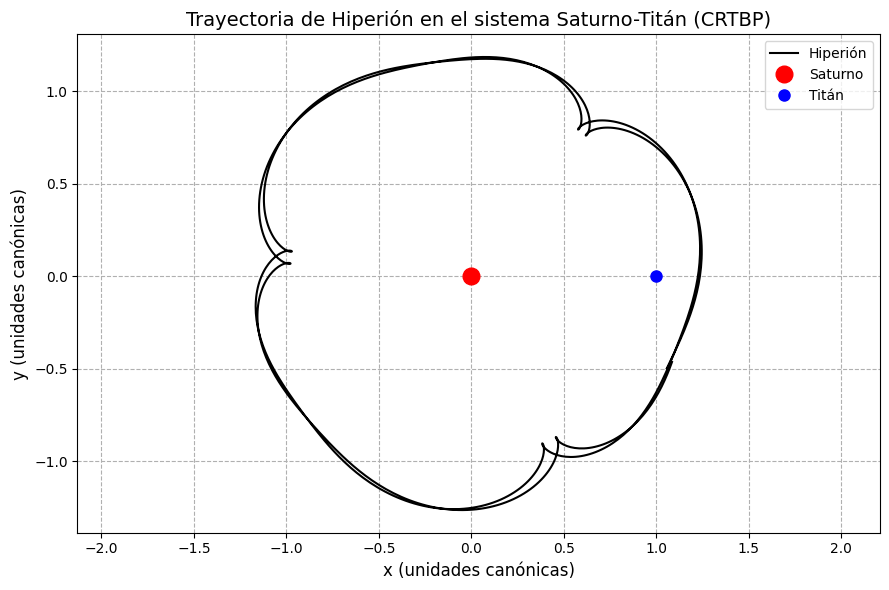

In [ ]:
plt.figure(figsize=(6*1.5, 4*1.5))

plt.plot(xs, ys, color='black', linewidth=1.5, label='Hiperión')

plt.plot(-alpha, 0, 'o', color='red', markersize=12, label='Saturno')
plt.plot(1 - alpha, 0, 'o', color='blue', markersize=8, label='Titán')

plt.xlabel('x (unidades canónicas)', fontsize=12)
plt.ylabel('y (unidades canónicas)', fontsize=12)
plt.title('Trayectoria de Hiperión en el sistema Saturno-Titán (CRTBP)', fontsize=14)

plt.grid(ls="--")
plt.axis('equal')

plt.legend()
plt.tight_layout();

# Sistema con datos de Horizons (canónico pero no rotante)

In [ ]:
def SistemaInternacional2Canonicas(estado_si):
    Y_s_Canonico = {}
    for id, df_SI in estado_si.items():
        df_Canonico = df_SI.copy()

        df_Canonico[['x', 'y', 'z']] = df_SI[['x', 'y', 'z']] / U_L

        df_Canonico[['vx', 'vy', 'vz']] = df_SI[['vx', 'vy', 'vz']] / U_V

        Y_s_Canonico[id] = df_Canonico
    return Y_s_Canonico
vector_estado_canonico = SistemaInternacional2Canonicas(vector_estado)

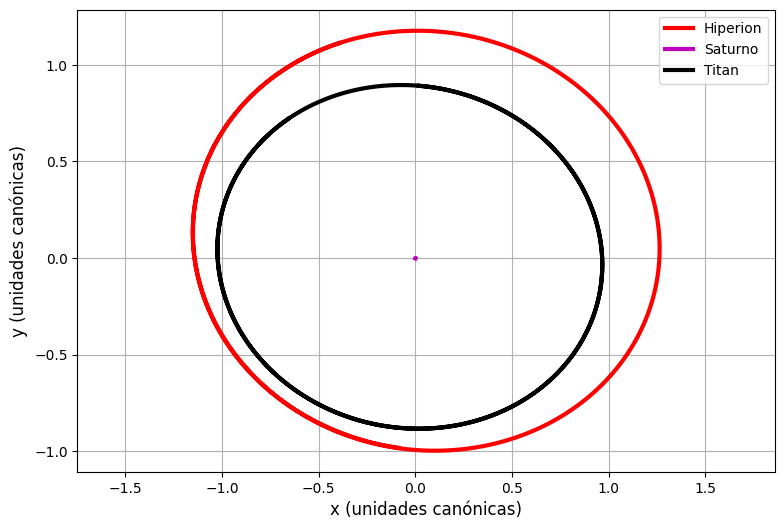

In [ ]:
elementos = {"Hiperion": "-r", "Saturno": "-m", "Titan": "-k"}


plt.figure(figsize=(6*1.5, 4*1.5))

for cuerpo, estilo in elementos.items():
    df = vector_estado_canonico[cuerpo]
    plt.plot(df["x"], df["y"], estilo, lw=3, label=cuerpo)


plt.xlabel('x (unidades canónicas)', fontsize=12)
plt.ylabel('y (unidades canónicas)', fontsize=12)
plt.axis('equal')
plt.grid()
plt.legend();